[2026-07-03 Fiddler](https://thefiddler.substack.com/p/can-you-fit-the-stars-on-the-flag)
====================

Fiddler
-------
By symmetry, we only need to consider $0 \le x \le 1/2$ and $0 \le y \le x$.

In the plot below, visually, the kite-ish region with its vertices marked in red
is the darkest, meaning that region is within a distance of 2 of the most number of
stars.

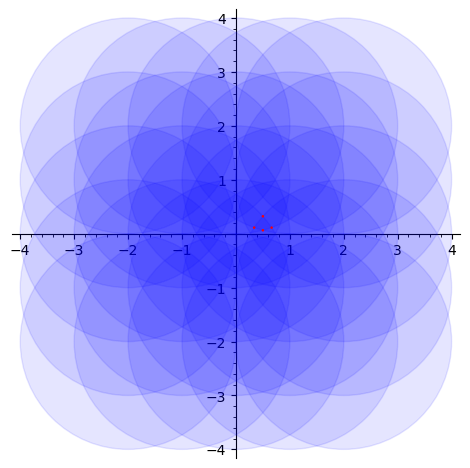

In [1]:
(sum([circle((x-2,y-2),2,fill=True,alpha=0.1) for x in range(5) for y in range(5)])
 + circle((1/2,2-sqrt(15)/2),0.01,color="red")
 + circle((3/2-3*sqrt(3/20),1/2-sqrt(3/20)),0.01,color="red")
 + circle((-1/2+3*sqrt(3/20),1/2-sqrt(3/20)),0.01,color="red")
 + circle((1/2,-1+sqrt(7)/2),0.01,color="red")
)

In [2]:
def count(x, y, r):
    return len([1 for i in [floor(x-r)..ceil(x+r)] for j in [floor(y-r)..ceil(y+r)] if (x-i)^2 + (y-j)^2 <= r^2])

In [3]:
count(0,0,2)

13

Consider where the stars at (0,2) and (1,2) are on the perimeter of the circle, putting
the center of the circle at $(1/2, 2-\sqrt{15}/2)$, the lower vertex of the kite-ish region.
This circle can contain 14 stars.

In [4]:
count(1/2,2-sqrt(15)/2,2)

14

In [5]:
def star(x,y):
    r1 = 0.2
    r2 = 0.08
    points = [(x+sin(k*2*pi/10)*(r1 if is_even(k) else r2),y+cos(k*2*pi/10)*(r1 if is_even(k) else r2)) for k in [0..9]]
    return polygon(points)

def region(x,y,r):
    return (sum([star(i,j) for i in [floor(x-r)..ceil(x+r)] for j in [floor(y-r)..ceil(y+r)] if (x-i)^2+(y-j)^2 <= r^2])
            + circle((x,y),r,alpha=0.2,fill=True,thickness=0,axes=False))

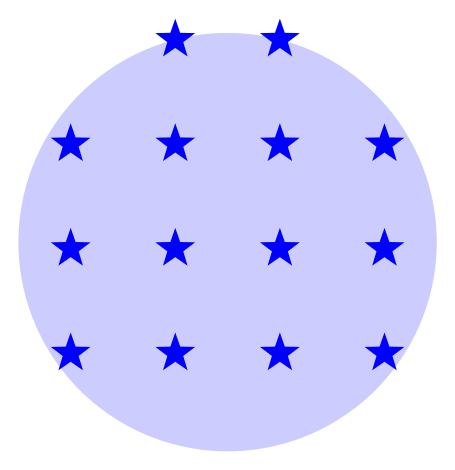

In [6]:
region(1/2,2-sqrt(15)/2,2)

The four circles centered at the vertices of the kite-ish region encompass the same
14 stars, in which

* the top two stars are on the perimeter
* the left-most and right-most stars in the bottom row are on the perimeter
* the left-most stars in the top row and bottom row are on the perimeter
* the right-most stars in the top row and bottom row are on the perimeter

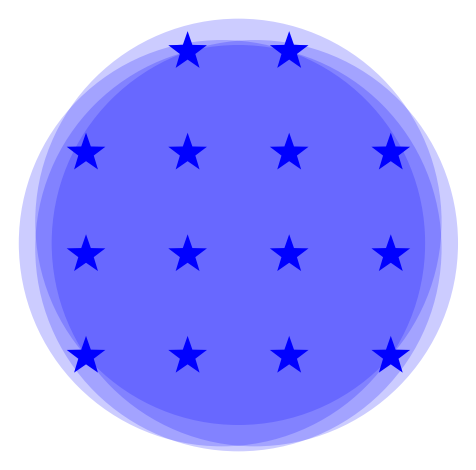

In [7]:
(circle((1/2,2-sqrt(15)/2),2,thickness=0,alpha=0.2,fill=True)
 + circle((3/2-3*sqrt(3/20),1/2-sqrt(3/20)),2,thickness=0,alpha=0.2,fill=True)
 + circle((-1/2+3*sqrt(3/20),1/2-sqrt(3/20)),2,thickness=0,alpha=0.2,fill=True)
 + region(1/2,-1+sqrt(7)/2,2))

Extra credit
------------

At least three stars must be on the perimeter of the circle, and those three points will
define the circle.

To get a first estimate, consider what the minimum radius is when the center of the circle
is at a star.

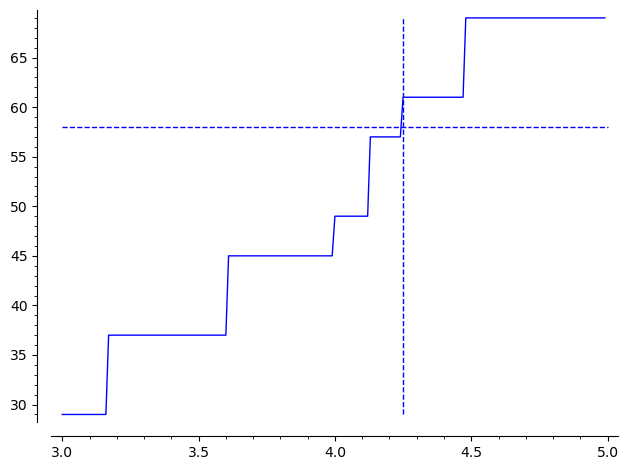

In [8]:
(line([(3,58),(5,58)],linestyle="dashed")
 + line([(3+2*i/200,count(0,0,3+2*i/200)) for i in range(200)])
 + line([(4.25,29),(4.25,69)],linestyle="dashed")
)

When the center of the circle is on a star,
the radius must be at least 17/4, so the diameter must be at least 17/2.

It encompasses 61 stars, so there probably are ways to shift the center and
reduce the radius and still encompass 58 stars.

61


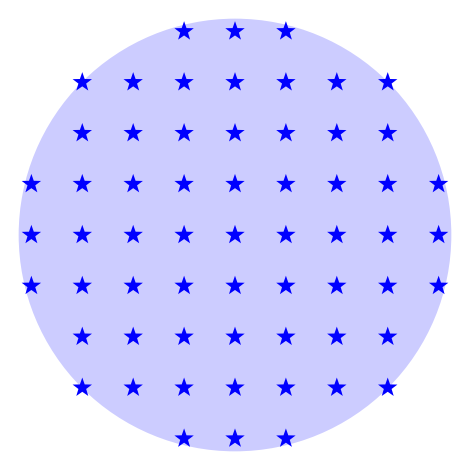

In [9]:
print(count(0,0,17/4))
region(0,0,17/4)

When doing an exhaustive search over all star triples, the three
stars cannot be more than 17/2 from each other, and the radius of the circle
they define must be less than or equal to 17/4.

In [10]:
x,y,x1,y1,x2,y2,x3,y3 = var("x,y,x1,y1,x2,y2,x3,y3")
solve([(x-x1)^2+(y-y1)^2 == (x-x2)^2+(y-y2)^2, (x-x2)^2+(y-y2)^2 == (x-x3)^2+(y-y3)^2], [x,y])

[[x == 1/2*((y1 - y3)*y2^2 + x1^2*y3 - x2^2*y3 + y1^2*y3 + (x2^2 - x3^2 - y3^2)*y1 - (x1^2 - x3^2 + y1^2 - y3^2)*y2)/((x2 - x3)*y1 - (x1 - x3)*y2 + x1*y3 - x2*y3), y == -1/2*((x1 - x3)*x2^2 + x1^2*x3 - (x2 - x3)*y1^2 + (x1 - x3)*y2^2 - (x3^2 + y3^2)*x1 - (x1^2 - x3^2 - y3^2)*x2)/((x2 - x3)*y1 - (x1 - x3)*y2 + x1*y3 - x2*y3)]]

In [11]:
def make_circle(x1,y1,x2,y2,x3,y3):
    d = (x2 - x3)*y1 - (x1 - x3)*y2 + x1*y3 - x2*y3
    if d == 0:
        return (0,0), 10000
    x = 1/2*((y1 - y3)*y2^2 + x1^2*y3 - x2^2*y3 + y1^2*y3 + (x2^2 - x3^2 - y3^2)*y1 - (x1^2 - x3^2 + y1^2 - y3^2)*y2)/d
    y = -1/2*((x1 - x3)*x2^2 + x1^2*x3 - (x2 - x3)*y1^2 + (x1 - x3)*y2^2 - (x3^2 + y3^2)*x1 - (x1^2 - x3^2 - y3^2)*x2)/d
    return (x,y), sqrt((x-x1)^2+(y-y1)^2)

In [12]:
def search():
    center_min = (0,0)
    r_min = 17/4
    for x2 in [0..8]:
        for y2 in [0..x2]:
            for x3 in [x2-8 .. 8]:
                for y3 in [y2-8 .. 8]:
                    center, r = make_circle(0,0,x2,y2,x3,y3)
                    if r < r_min:
                        n = count(center[0], center[1], r)
                        if n >= 58:
                            print((0,0),(x2,y2),(x3,y3),center,r)
                            center_min, r_min = center, r
    return center_min, r_min

In [13]:
search()

(0, 0) (1, 0) (-1, -8) (1/2, -33/8) 1/8*sqrt(1105)


((1/2, -33/8), 1/8*sqrt(1105))

As it turns out, there are four stars on the perimeter of the circle:
the two in the top row, and the left-most and right most in the bottom
row.  And the minimum radius is $\sqrt{1105}/8 \approx 4.155$.

58
4.15519253464867


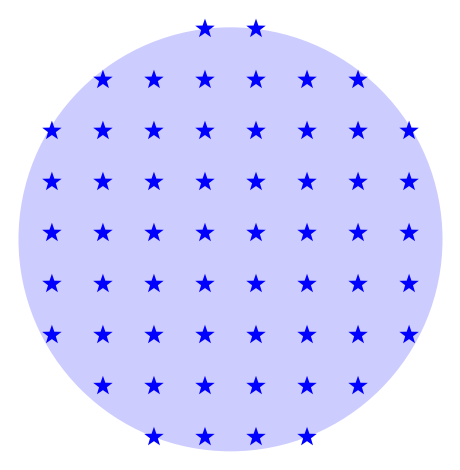

In [14]:
print(count(1/2,-33/8,sqrt(1105)/8))
print(numerical_approx(sqrt(1105)/8))
region(1/2,-33/8,sqrt(1105)/8)